## Load Required Libraries and Datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titlepad'] = 12

# Load data
file_path = "cleaned_data.csv"  # Update path as needed
data = pd.read_csv(file_path, parse_dates=['DATE'])

## Select Control Stores

The client has selected store numbers **77, 86, and 88** as trial stores and wants control stores to be
established stores that are operational for the entire observation period.

We match trial stores to control stores that are similar in the **pre-trial period (before Feb 2019)** based on:
- Monthly overall sales revenue
- Monthly number of customers
- Monthly number of transactions per customer

First, create the metrics of interest and filter to stores present throughout the entire pre-trial period.

In [3]:
# Create a year-month identifier
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month

# Calculate measures over time for each store
measure_over_time = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    totSales=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', 'nunique'),
    nTxnPerCust=('TXN_ID', lambda x: x.nunique() / data.loc[x.index, 'LYLTY_CARD_NBR'].nunique()),
    nChipsPerTxn=('PROD_QTY', lambda x: x.sum() / data.loc[x.index, 'TXN_ID'].nunique()),
    avgPricePerUnit=('TOT_SALES', lambda x: x.sum() / data.loc[x.index, 'PROD_QTY'].sum())
).reset_index().sort_values(['STORE_NBR', 'YEARMONTH'])

# Filter to stores with full observation periods (12 months pre-trial)
store_month_counts = measure_over_time.groupby('STORE_NBR')['YEARMONTH'].count()
stores_with_full_obs = store_month_counts[store_month_counts == 12].index.tolist()

pre_trial_measures = measure_over_time[
    (measure_over_time['YEARMONTH'] < 201902) &
    (measure_over_time['STORE_NBR'].isin(stores_with_full_obs))
].copy()

print(f"Stores with full observation: {len(stores_with_full_obs)}")
pre_trial_measures.head()

Stores with full observation: 259


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,188.9,47,1.042553,1.183673,3.256897
1,1,201808,168.4,41,1.000000,1.268293,3.238462
2,1,201809,268.1,57,1.035088,1.203390,3.776056
3,1,201810,175.4,39,1.025641,1.275000,3.439216
4,1,201811,184.8,44,1.022727,1.222222,3.360000


### Similarity Functions

We rank control stores by similarity using two approaches:
1. **Correlation** — how closely a store's trend matches the trial store's trend
2. **Magnitude distance** — how close the absolute values are (standardised 0–1)

A composite score is formed by averaging the two.

In [4]:
def calculate_correlation(input_table, metric_col, store_comparison):
    """Calculate correlation between trial store and every other store for a given metric."""
    store_numbers = input_table['STORE_NBR'].unique()
    results = []
    trial_series = input_table[input_table['STORE_NBR'] == store_comparison][metric_col].values

    for store in store_numbers:
        control_series = input_table[input_table['STORE_NBR'] == store][metric_col].values
        if len(trial_series) == len(control_series):
            corr = np.corrcoef(trial_series, control_series)[0, 1]
        else:
            corr = np.nan
        results.append({'Store1': store_comparison, 'Store2': store, 'corr_measure': corr})

    return pd.DataFrame(results)


def calculate_magnitude_distance(input_table, metric_col, store_comparison):
    """Calculate standardised magnitude distance between trial store and every other store."""
    store_numbers = input_table['STORE_NBR'].unique()
    results = []
    trial_data = input_table[input_table['STORE_NBR'] == store_comparison][['YEARMONTH', metric_col]].set_index('YEARMONTH')

    for store in store_numbers:
        control_data = input_table[input_table['STORE_NBR'] == store][['YEARMONTH', metric_col]].set_index('YEARMONTH')
        combined = trial_data.join(control_data, lsuffix='_trial', rsuffix='_control', how='inner')
        combined['measure'] = (combined[f'{metric_col}_trial'] - combined[f'{metric_col}_control']).abs()
        for ym, row in combined.iterrows():
            results.append({'Store1': store_comparison, 'Store2': store, 'YEARMONTH': ym, 'measure': row['measure']})

    dist_table = pd.DataFrame(results)

    # Standardise: 1 = closest (distance 0), 0 = furthest
    min_max = dist_table.groupby(['Store1', 'YEARMONTH'])['measure'].agg(['min', 'max']).reset_index()
    min_max.columns = ['Store1', 'YEARMONTH', 'minDist', 'maxDist']
    dist_table = dist_table.merge(min_max, on=['Store1', 'YEARMONTH'])
    dist_table['magnitudeMeasure'] = 1 - (dist_table['measure'] - dist_table['minDist']) / \
                                         (dist_table['maxDist'] - dist_table['minDist'])

    final = dist_table.groupby(['Store1', 'Store2'])['magnitudeMeasure'].mean().reset_index()
    final.columns = ['Store1', 'Store2', 'mag_measure']
    return final

### Helper: Score and Select Control Store

In [5]:
def get_control_store(pre_trial_measures, trial_store, corr_weight=0.5):
    """Return the best-matching control store number for a given trial store."""
    corr_sales = calculate_correlation(pre_trial_measures, 'totSales', trial_store)
    corr_custs = calculate_correlation(pre_trial_measures, 'nCustomers', trial_store)
    mag_sales  = calculate_magnitude_distance(pre_trial_measures, 'totSales', trial_store)
    mag_custs  = calculate_magnitude_distance(pre_trial_measures, 'nCustomers', trial_store)

    score_sales = corr_sales.merge(mag_sales, on=['Store1', 'Store2'])
    score_sales['scoreNSales'] = score_sales['corr_measure'] * corr_weight + score_sales['mag_measure'] * (1 - corr_weight)

    score_custs = corr_custs.merge(mag_custs, on=['Store1', 'Store2'])
    score_custs['scoreNCust'] = score_custs['corr_measure'] * corr_weight + score_custs['mag_measure'] * (1 - corr_weight)

    score_control = score_sales[['Store1', 'Store2', 'scoreNSales']].merge(
        score_custs[['Store1', 'Store2', 'scoreNCust']], on=['Store1', 'Store2']
    )
    score_control['finalControlScore'] = score_control['scoreNSales'] * 0.5 + score_control['scoreNCust'] * 0.5
    score_control = score_control.sort_values('finalControlScore', ascending=False)

    # Second highest score (first is the trial store itself)
    control_store = score_control[score_control['Store2'] != trial_store].iloc[0]['Store2']
    return int(control_store)

### Helper: Plot Pre-Trial Trends

In [6]:
def plot_pre_trial(measure_over_time, trial_store, control_store, metric, ylabel, title):
    """Plot metric trends for trial, control, and other stores before the trial period."""
    df = measure_over_time.copy()
    df['Store_type'] = df['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
    )
    grouped = df[df['YEARMONTH'] < 201903].groupby(['YEARMONTH', 'Store_type'])[metric].mean().reset_index()
    grouped['TransactionMonth'] = pd.to_datetime(
        grouped['YEARMONTH'].astype(str).str[:4] + '-' + grouped['YEARMONTH'].astype(str).str[4:] + '-01'
    )

    colors = {'Trial': 'steelblue', 'Control': 'tomato', 'Other stores': 'seagreen'}
    fig, ax = plt.subplots()
    for store_type, grp in grouped.groupby('Store_type'):
        ax.plot(grp['TransactionMonth'], grp[metric], label=store_type, color=colors[store_type])
    ax.set_xlabel('Month of operation')
    ax.set_ylabel(ylabel)
    ax.set_title(title, ha='center')
    ax.legend(title='Store_type')
    plt.tight_layout()
    plt.show()

### Helper: Assess Trial Impact

In [7]:
def assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store, metric, ylabel, title):
    """Scale control store, compute t-values, and plot trial assessment with confidence bands."""

    # --- Scale control to match trial in pre-trial period ---
    trial_pretrial  = pre_trial_measures[pre_trial_measures['STORE_NBR'] == trial_store][metric].sum()
    control_pretrial = pre_trial_measures[pre_trial_measures['STORE_NBR'] == control_store][metric].sum()
    scaling_factor = trial_pretrial / control_pretrial

    control_data = measure_over_time[measure_over_time['STORE_NBR'] == control_store].copy()
    control_data['scaledMetric'] = control_data[metric] * scaling_factor

    trial_data = measure_over_time[measure_over_time['STORE_NBR'] == trial_store][['YEARMONTH', metric]].copy()

    merged = control_data[['YEARMONTH', 'scaledMetric']].merge(trial_data, on='YEARMONTH')
    merged['percentageDiff'] = (merged['scaledMetric'] - merged[metric]).abs() / merged['scaledMetric']

    # Standard deviation from pre-trial period
    std_dev = merged[merged['YEARMONTH'] < 201902]['percentageDiff'].std()
    degrees_of_freedom = 7  # 8 pre-trial months - 1

    # Print t-values for trial months
    trial_months = merged[(merged['YEARMONTH'] > 201901) & (merged['YEARMONTH'] < 201905)].copy()
    trial_months['tValue'] = trial_months['percentageDiff'] / std_dev
    t_critical = stats.t.ppf(0.95, df=degrees_of_freedom)
    print(f"\nTrial store {trial_store} | Control store {control_store} | Metric: {metric}")
    print(trial_months[['YEARMONTH', 'percentageDiff', 'tValue']].to_string(index=False))
    print(f"95th percentile t-value (df={degrees_of_freedom}): {t_critical:.4f}")

    # --- Build plotting data ---
    plot_df = measure_over_time[
        measure_over_time['STORE_NBR'].isin([trial_store, control_store])
    ].copy()
    plot_df['Store_type'] = plot_df['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store else 'Control'
    )
    plot_df = plot_df.groupby(['YEARMONTH', 'Store_type'])[metric].mean().reset_index()
    plot_df['TransactionMonth'] = pd.to_datetime(
        plot_df['YEARMONTH'].astype(str).str[:4] + '-' + plot_df['YEARMONTH'].astype(str).str[4:] + '-01'
    )

    control_plot = plot_df[plot_df['Store_type'] == 'Control'].copy()
    control_plot_95 = control_plot.copy()
    control_plot_95[metric] = control_plot_95[metric] * (1 + std_dev * 2)
    control_plot_5  = control_plot.copy()
    control_plot_5[metric]  = control_plot_5[metric] * (1 - std_dev * 2)

    # --- Plot ---
    fig, ax = plt.subplots()

    # Shade trial period
    trial_start = pd.Timestamp('2019-02-01')
    trial_end   = pd.Timestamp('2019-04-01')
    ax.axvspan(trial_start, trial_end, color='grey', alpha=0.3, label='_nolegend_')

    ax.plot(plot_df[plot_df['Store_type']=='Trial']['TransactionMonth'],
            plot_df[plot_df['Store_type']=='Trial'][metric], label='Trial', color='mediumpurple')
    ax.plot(control_plot['TransactionMonth'], control_plot[metric],
            label='Control', color='tomato')
    ax.plot(control_plot_95['TransactionMonth'], control_plot_95[metric],
            label='Control 95th % confidence interval', color='steelblue', linestyle='--')
    ax.plot(control_plot_5['TransactionMonth'], control_plot_5[metric],
            label='Control 5th % confidence interval', color='seagreen', linestyle=':')

    ax.set_xlabel('Month of operation')
    ax.set_ylabel(ylabel)
    ax.set_title(title, ha='center')
    ax.legend(title='Store_type', fontsize=8)
    plt.tight_layout()
    plt.show()

---
## Trial Store 77

### Find Control Store

In [8]:
trial_store = 77
control_store = get_control_store(pre_trial_measures, trial_store)
print(f"Control store for trial store {trial_store}: {control_store}")

Control store for trial store 77: 233


### Visual Check: Pre-Trial Trends (Store 77)

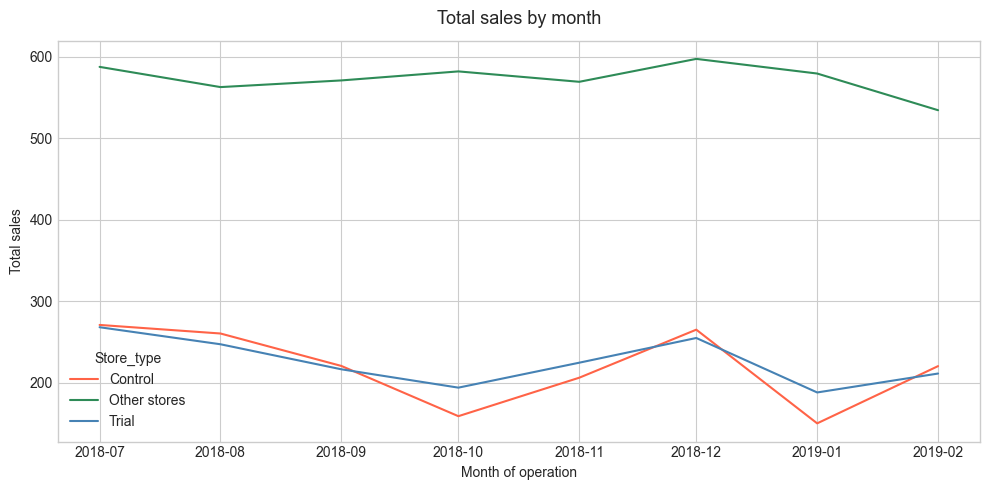

In [9]:
plot_pre_trial(measure_over_time, trial_store, control_store,
               'totSales', 'Total sales', 'Total sales by month')

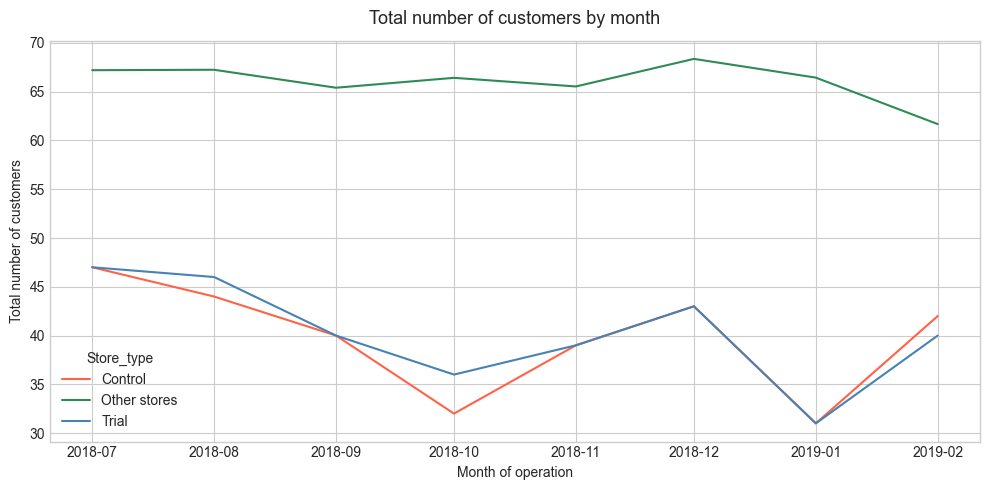

In [10]:
plot_pre_trial(measure_over_time, trial_store, control_store,
               'nCustomers', 'Total number of customers', 'Total number of customers by month')

### Assessment of Trial — Store 77

The trial period runs from **March 2019 to May 2019**. We scale the control store's sales to the pre-trial
level of the trial store, then assess whether differences during the trial period are statistically significant.

The null hypothesis is that the trial period is the same as the pre-trial period (i.e. no uplift).
The standard deviation is derived from pre-trial percentage differences, giving 7 degrees of freedom.


Trial store 77 | Control store 233 | Metric: totSales
 YEARMONTH  percentageDiff    tValue
    201902        0.077889  1.223912
    201903        0.358510  5.633494
    201904        0.721444 11.336505
95th percentile t-value (df=7): 1.8946


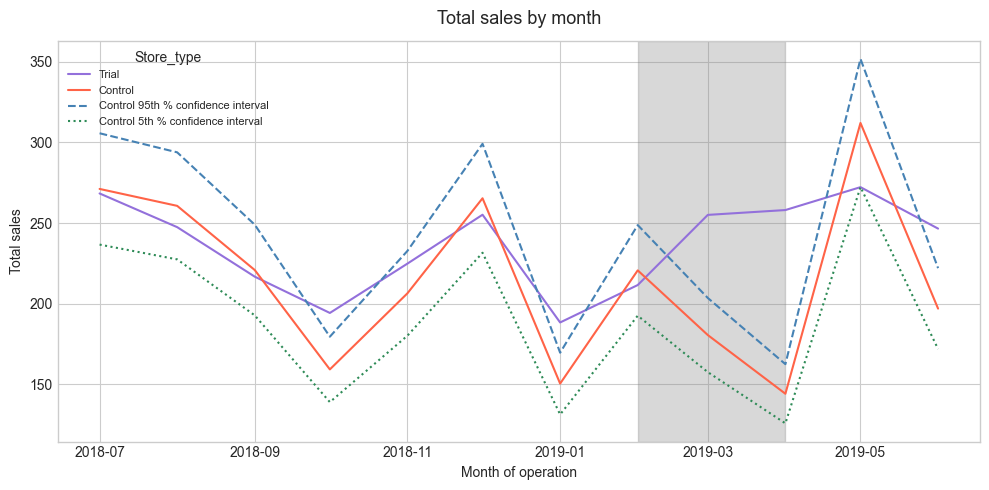

In [11]:
assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store,
             'totSales', 'Total sales', 'Total sales by month')


Trial store 77 | Control store 233 | Metric: nCustomers
 YEARMONTH  percentageDiff    tValue
    201902        0.067882  2.259470
    201903        0.286322  9.530240
    201904        0.703704 23.422793
95th percentile t-value (df=7): 1.8946


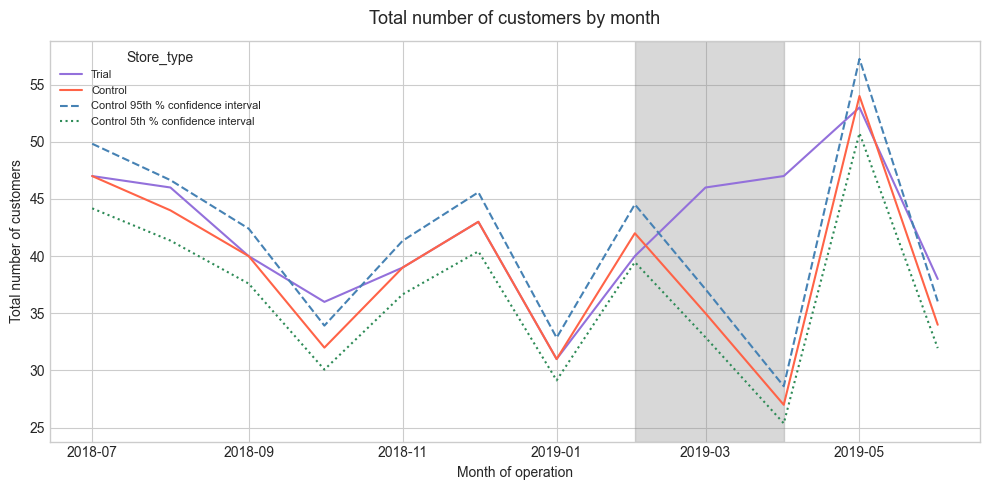

In [12]:
assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store,
             'nCustomers', 'Total number of customers', 'Total number of customers by month')

> **Result — Store 77:** The trial store's performance lies outside the 5%–95% confidence interval of the control store
> in **two of the three trial months** for both total sales and number of customers, indicating a **significant positive trial effect**.

---
## Trial Store 86

### Find Control Store

In [13]:
trial_store = 86
control_store = get_control_store(pre_trial_measures, trial_store)
print(f"Control store for trial store {trial_store}: {control_store}")

Control store for trial store 86: 155


### Visual Check: Pre-Trial Trends (Store 86)

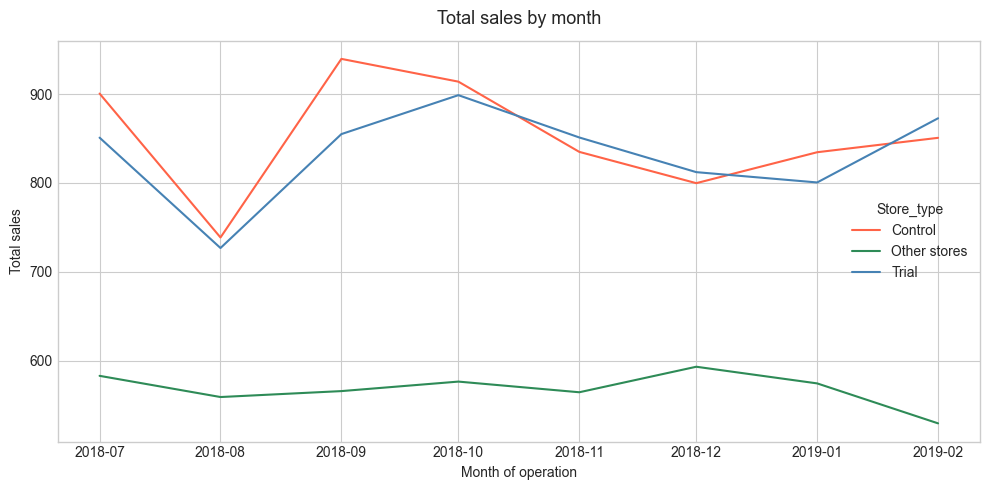

In [14]:
plot_pre_trial(measure_over_time, trial_store, control_store,
               'totSales', 'Total sales', 'Total sales by month')

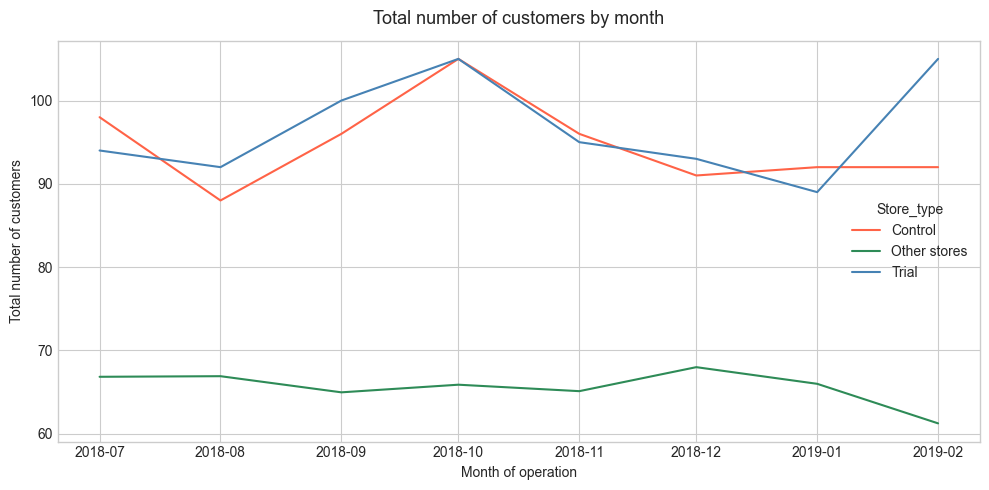

In [15]:
plot_pre_trial(measure_over_time, trial_store, control_store,
               'nCustomers', 'Total number of customers', 'Total number of customers by month')

### Assessment of Trial — Store 86


Trial store 86 | Control store 155 | Metric: totSales
 YEARMONTH  percentageDiff    tValue
    201902        0.055356  2.642804
    201903        0.268037 12.796638
    201904        0.033381  1.593697
95th percentile t-value (df=7): 1.8946


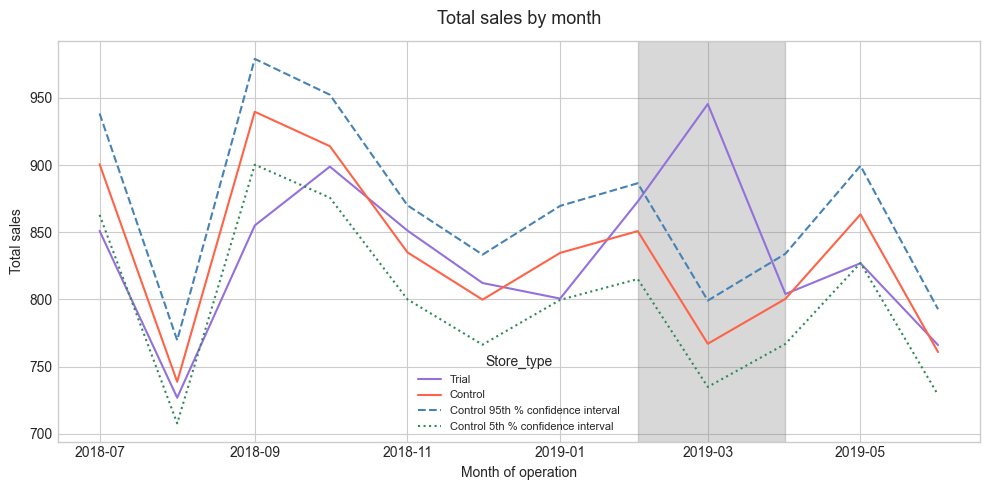

In [16]:
assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store,
             'totSales', 'Total sales', 'Total sales by month')


Trial store 86 | Control store 155 | Metric: nCustomers
 YEARMONTH  percentageDiff    tValue
    201902        0.137887  8.605720
    201903        0.183260 11.437481
    201904        0.061329  3.827618
95th percentile t-value (df=7): 1.8946


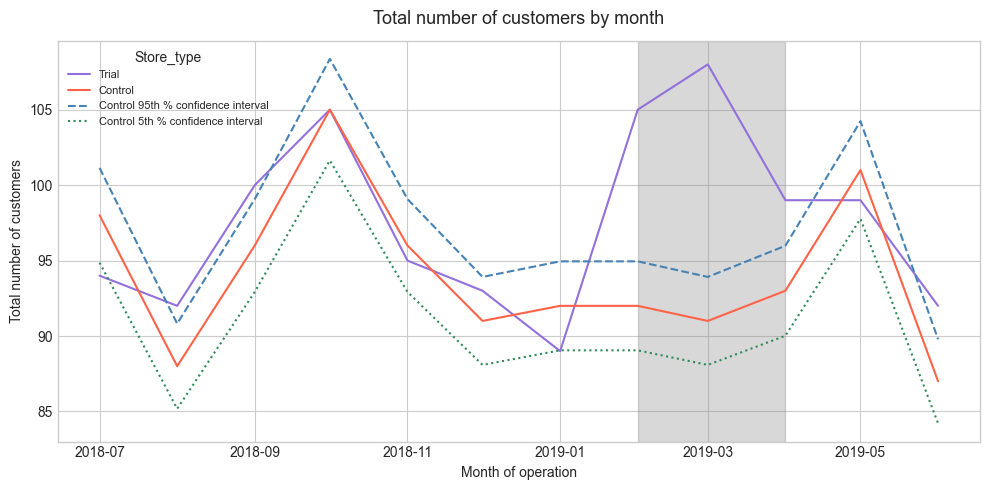

In [17]:
assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store,
             'nCustomers', 'Total number of customers', 'Total number of customers by month')

> **Result — Store 86:** Total sales are **not significantly different** to the control store (within the confidence interval
> for two of three trial months). However, the number of customers **is significantly higher** in all three months.
> This may suggest special deals lowered unit prices, inflating customer count without lifting total revenue.
> Worth checking with the Category Manager.

---
## Trial Store 88

### Find Control Store

In [18]:
trial_store = 88
control_store = get_control_store(pre_trial_measures, trial_store)
print(f"Control store for trial store {trial_store}: {control_store}")

Control store for trial store 88: 237


### Visual Check: Pre-Trial Trends (Store 88)

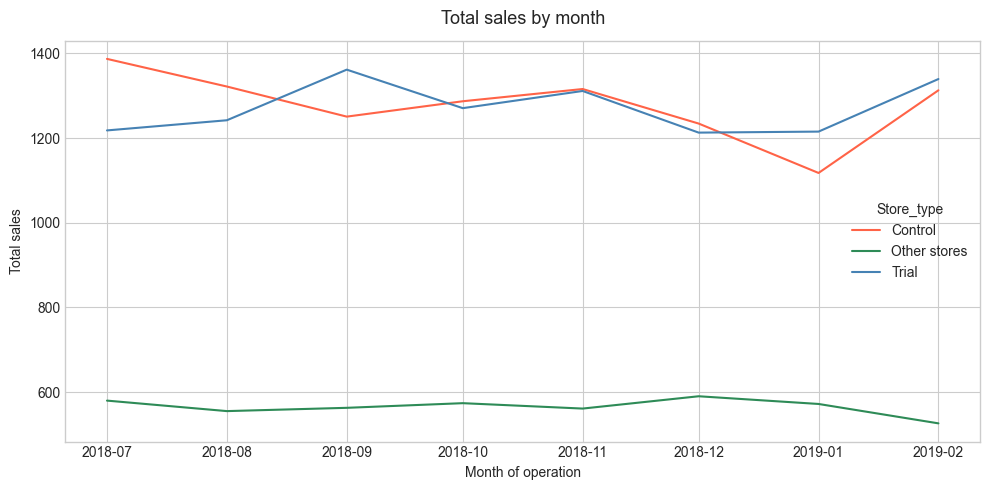

In [19]:
plot_pre_trial(measure_over_time, trial_store, control_store,
               'totSales', 'Total sales', 'Total sales by month')

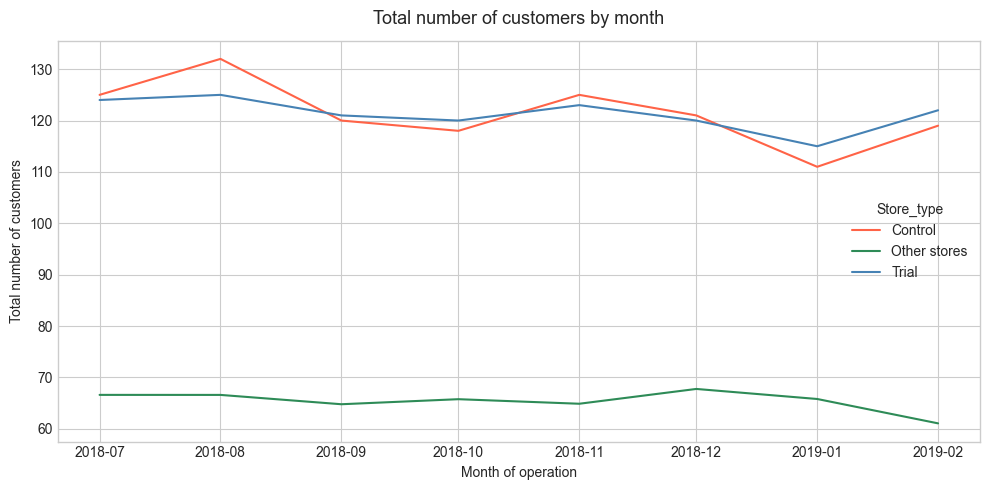

In [20]:
plot_pre_trial(measure_over_time, trial_store, control_store,
               'nCustomers', 'Total number of customers', 'Total number of customers by month')

### Assessment of Trial — Store 88


Trial store 88 | Control store 237 | Metric: totSales
 YEARMONTH  percentageDiff   tValue
    201902        0.029765 0.606487
    201903        0.257361 5.243910
    201904        0.152281 3.102824
95th percentile t-value (df=7): 1.8946


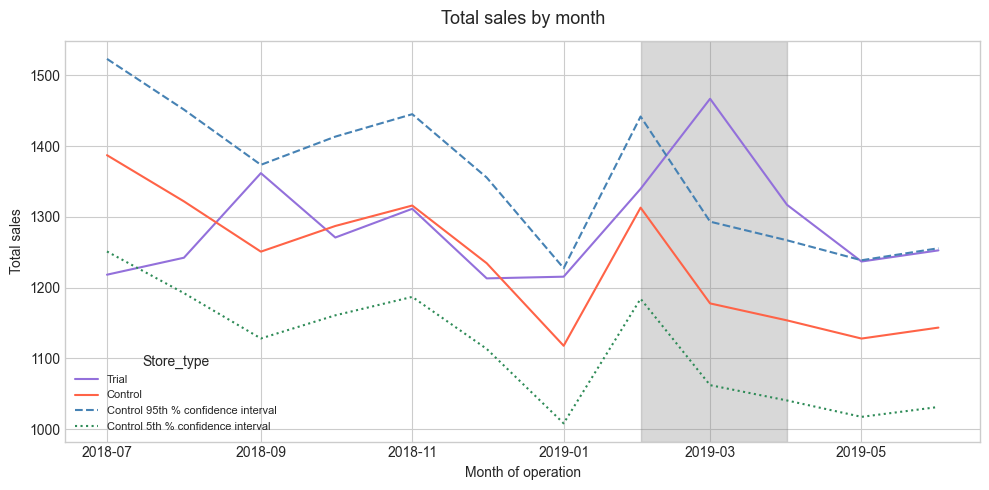

In [21]:
assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store,
             'totSales', 'Total sales', 'Total sales by month')


Trial store 88 | Control store 237 | Metric: nCustomers
 YEARMONTH  percentageDiff   tValue
    201902        0.030046 1.677105
    201903        0.151960 8.482095
    201904        0.030701 1.713669
95th percentile t-value (df=7): 1.8946


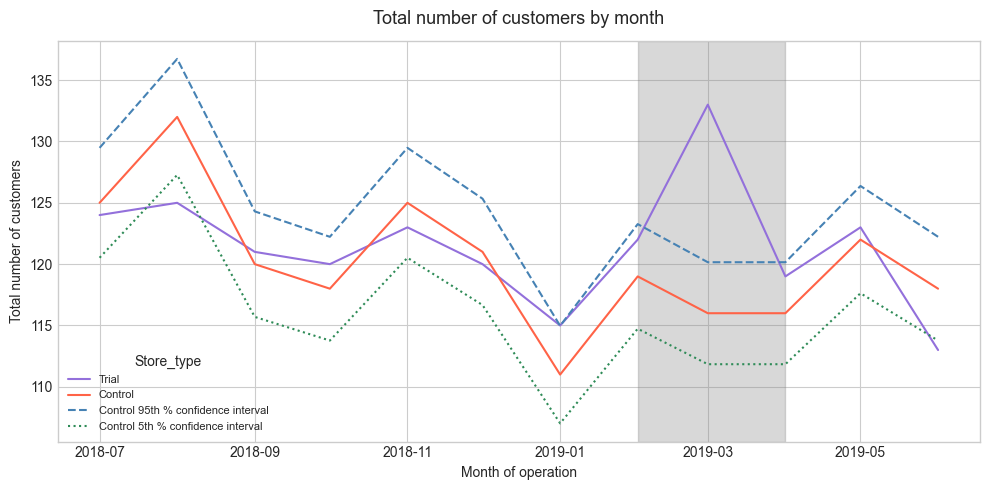

In [22]:
assess_trial(measure_over_time, pre_trial_measures, trial_store, control_store,
             'nCustomers', 'Total number of customers', 'Total number of customers by month')

> **Result — Store 88:** Both total sales and number of customers are **significantly higher** than the control store
> in two out of three trial months, indicating a **strong positive trial effect**.

---
## Conclusion

Control stores were identified as follows:

| Trial Store | Control Store |
|-------------|---------------|
| 77          | 233           |
| 86          | 155           |
| 88          | 237           |

The results for **trial stores 77 and 88** show a statistically significant increase in sales during the trial
period (performance outside the 5%–95% confidence interval in at least two of three trial months).

**Trial store 86** did not show significantly higher sales, though customer numbers did increase significantly.
We should check with the client whether the trial was implemented differently at store 86 — for example,
promotional pricing may have attracted more customers but reduced the average transaction value.

Overall, the trial shows a **significant increase in sales** and we can proceed to prepare the presentation
for the Category Manager.